In [27]:
import torch
from torch import nn, Tensor, no_grad, save, load
from torch import optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from PIL import Image

import os
import pandas as pd
import numpy as np
import time
from tqdm import tqdm

import matplotlib.pyplot as plt

from typing import Callable, List, Tuple

In [28]:
df = pd.read_csv("raw_data\cleaned_dataset.csv")
#df.drop(columns=["description", "Material", "Occasion", "Length", "Size", "Brand", "Seasons", "Gender", "Fit"], inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Beatriz Rodrigues\AppData\Local\Temp\ipykernel_3020\3163463127.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv("raw_data\cleaned_dataset.csv")


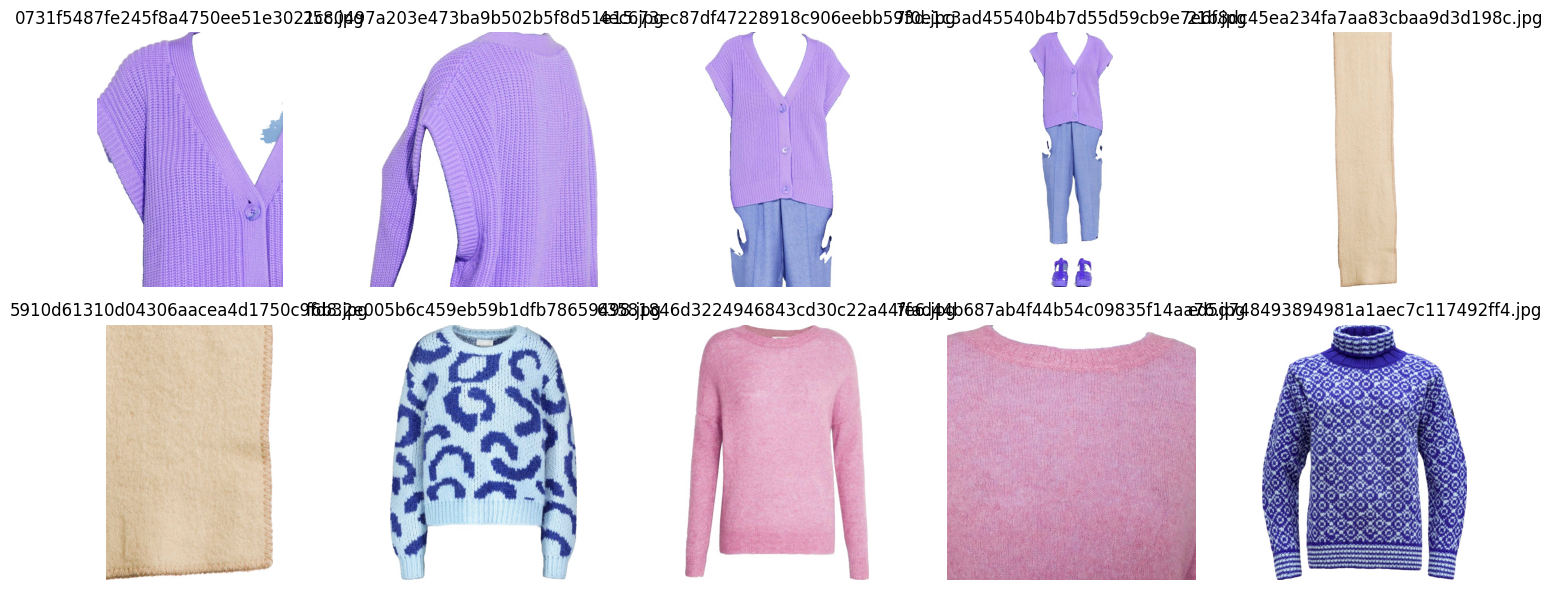

In [30]:
# Defina a categoria que você quer visualizar
categoria_desejada = "Knitwear"  # substitua pelo nome da categoria que você quer

# Filtra o DataFrame pela categoria desejada
df_filtrado = df[df['Category'] == categoria_desejada].head(10)

# Define o caminho da pasta onde estão as imagens
caminho_imagens = "images/"

# Número de colunas para o grid de exibição
colunas = 5
linhas = (len(df_filtrado) + colunas - 1) // colunas

# Cria a figura para exibir as imagens
plt.figure(figsize=(15, 3 * linhas))

for i, nome_arquivo in enumerate(df_filtrado['file_name']):
    caminho_arquivo = os.path.join(caminho_imagens, nome_arquivo)
    
    try:
        imagem = Image.open(caminho_arquivo)
        plt.subplot(linhas, colunas, i + 1)
        plt.imshow(imagem)
        plt.axis('off')
        plt.title(f"{nome_arquivo}")
    except Exception as e:
        print(f"Erro ao carregar {nome_arquivo}: {e}")

plt.tight_layout()
plt.show()


In [31]:
df = df[df['Category'] != "Knitwear"]

In [32]:
category_map = {
    'Blouses': 'Blouses',
    'Dresses': 'Dresses',
    'Jumpsuits': 'Jumpsuits',
    'Skirts': 'Skirts',
    'Sweaters': 'Pullovers',
    'Tops': 'Tops',
    'Coats': 'Coats',
    'Trousers': 'Trousers',
    'Jackets': 'Coats',
    'Shirts': 'Shirts',
    'Cardigans': 'Pullovers',
    'Shorts': 'Shorts',
    'Vests': 'Pullovers',
    'Blazers': 'Coats'
}

# Cria nova coluna com a categoria mapeada
df['mapped_category'] = df['Category'].map(category_map)

# Remove linhas que não conseguiram ser mapeadas (nan)
df = df.dropna(subset=['mapped_category'])

In [33]:
class ClothesDataset(Dataset):
    def __init__(self, 
            df:pd.DataFrame, 
            label_column: str,
            labels:List[str],
            transform:Callable[[np.ndarray], Tensor]=transforms.ToTensor(), 
            path_images:str="./images", 
            filename_column: str='file_name', 
        ) -> None:
        if label_column not in df.columns:
            raise ValueError(f"label column '{label_column}' not found in DataFrame")      
        self.path_files = path_images
        self.label_column = label_column
        self.filename_column = filename_column
        self.labels = labels
        self.df = df.dropna(subset=[label_column])  # remove linhas sem categoria
        self.transform = transform
        
        self.parse_label = {}
        self.parse_label = {label: idx for idx, label in enumerate(labels)}

    def __len__(self) -> int:
        return len(self.df)
    
    def num_labels(self) -> int:
        return len(self.labels)
    
    def true_labels(self, indexed:bool=False) -> List[str]:
        if indexed:
            return self.df[self.label_column].apply(lambda x: self.parse_label[x]).tolist()
        return self.df[self.label_column].tolist()

    def __getitem__(self, idx:int) -> Tuple[Tensor, int]:
        row = self.df.iloc[idx]
        
        label = self.parse_label[row[self.label_column]]
        
        image_path = os.path.join(self.path_files, row[self.filename_column])
        if not os.path.isfile(image_path):
            raise FileNotFoundError(f"Image file '{image_path}' not found")
        image = Image.open(image_path).convert("RGB")

        image = self.transform(image)

        return image, label

In [35]:
image_size = (64, 64)

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.Grayscale(),
    transforms.ToTensor(),
])

label_column = "mapped_category"
labels = df[label_column].dropna().sort_values().unique().tolist()  
labels    

['Blouses',
 'Coats',
 'Dresses',
 'Jumpsuits',
 'Pullovers',
 'Shirts',
 'Shorts',
 'Skirts',
 'Tops',
 'Trousers']

In [ ]:
# divisão de df com o de teste balanceado por categoria

df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

contagem = df_test['mapped_category'].value_counts()
minimo = contagem.min()
df_balanceado = df_test.groupby('mapped_category').sample(n=minimo, random_state=42).reset_index(drop=True)

In [ ]:
train_dataset = ClothesDataset(df_train, label_column, labels, transform=transform, path_images="./images")
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = ClothesDataset(df_balanceado, label_column, labels, transform=transform, path_images="./images")
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [37]:
class Net(nn.Module):
    def __init__(self, img_size:Tuple[int, int], num_labels:int):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.2)

        # Para imagens 64x64
        self.flatten_size = 64 * 31 * 31

        self.fc1 = nn.Linear(self.flatten_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_labels)  # Ajusta se não for 10 classes

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = F.relu(self.conv1(x))          # [B, 64, 126, 126]
        x = self.pool(x)                   # [B, 64, 63, 63]
        x = self.dropout(x)
        x = x.view(-1, self.flatten_size)  # Flatten
        x = F.relu(self.fc1(x))            # [B, 64]
        x = F.relu(self.fc2(x))            # [B, 32]
        x = self.fc3(x)                    # [B, 10]
        return x

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Net(image_size, train_dataset.num_labels())
model.to(device)
print(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

cpu


In [38]:
epochs = 10

running_losses = []
batch_losses = []

total_batches = epochs * len(train_dataloader)
progress_bar = tqdm(total=total_batches, desc="Training Progress", position=0, bar_format='{l_bar}{bar:20}{r_bar}')

start_time = time.time()
model.train()
for epoch in range(epochs):
    epoch_running_loss = 0
    for i, batch in enumerate(train_dataloader):
        imgs, labels = batch
        optimizer.zero_grad()
        output = model(imgs.to(device))
        
        loss = criterion(output, labels.to(device))
        loss.backward()
        optimizer.step()

        loss_batch = loss.item()
        
        epoch_running_loss += loss_batch
        
        progress_bar.update(1)
        progress_bar.set_postfix(epoch=epoch+1, batch=i+1, loss=round(loss.item(), 2))
        batch_losses.append(loss_batch)
        #progress_bar.set_postfix(epoch=epoch+1, batch=i+1, loss=round(loss.item()/len(batch), 2))
        
    running_losses.append(epoch_running_loss)
progress_bar.close()

Training Progress: 100%|████████████████████| 9010/9010 [52:04<00:00,  2.88it/s, batch=901, epoch=10, loss=0.1] 


In [ ]:
if not os.path.exists(f"./models"):
    os.makedirs(f"./models")

save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "time": time.time() - start_time,
        "running_losses": running_losses,
        "batch_losses": batch_losses
    }, 
    os.path.join(f"./models/model_{label_column}_img64.pt")
)

In [40]:
correct = 0
pred_labels = []

total_batches = len(test_dataloader)
progress_bar = tqdm(total=total_batches, desc="Test Progress", position=0, bar_format='{l_bar}{bar:20}{r_bar}')

start_time = time.time()
model.eval()
with no_grad():
    for i, batch in enumerate(test_dataloader):
        imgs, labels = batch
        output = model(imgs.to(device))
            
        _, prediction = torch.max(output.data, 1)
        correct += (prediction == labels.to(device)).sum().item()
        pred_labels += prediction.cpu().tolist()
        
        progress_bar.update(1)
        progress_bar.set_postfix(batch=i+1, accuracy=round(correct/len(pred_labels), 2))
    progress_bar.close()

Test Progress: 100%|████████████████████| 7/7 [00:06<00:00,  1.11it/s, accuracy=0.63, batch=7]


In [41]:
labels = df[label_column].dropna().sort_values().unique().tolist() 

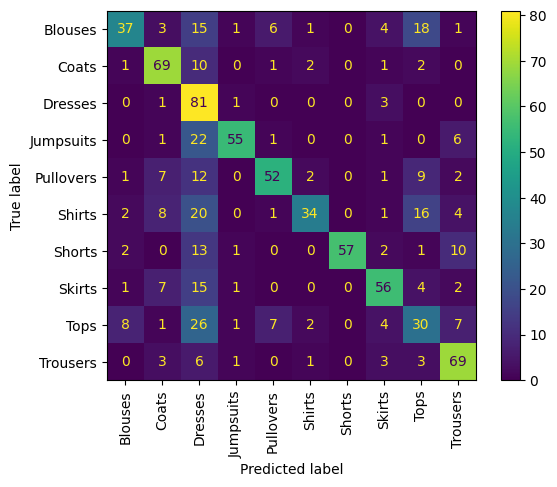

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrix = confusion_matrix(test_dataset.true_labels(True), pred_labels)
ConfusionMatrixDisplay(matrix, display_labels=labels).plot(xticks_rotation="vertical")

In [43]:
# Caminho para o arquivo salvo
checkpoint_path = f"./models/model_{label_column}_1conv.pt"

# Carrega o checkpoint
checkpoint = torch.load(checkpoint_path)

# Acessa o batch_losses
batch_losses = checkpoint["batch_losses"]

# Agora você pode usar batch_losses normalmente
print(batch_losses)

[2.2521519660949707, 14.530914306640625, 7.640986919403076, 5.50128698348999, 5.118133068084717, 3.5810956954956055, 2.2639319896698, 3.530285596847534, 1.945662021636963, 3.383620500564575, 2.6080033779144287, 2.421848773956299, 2.314694404602051, 2.57920241355896, 2.2189033031463623, 1.7544358968734741, 1.7594646215438843, 1.940293788909912, 1.96089768409729, 1.7157139778137207, 2.18621826171875, 2.167827844619751, 2.0366172790527344, 1.8675931692123413, 1.7130483388900757, 1.3878096342086792, 1.7386326789855957, 1.389591932296753, 1.8524174690246582, 1.774439811706543, 1.908577799797058, 1.8813693523406982, 1.7431148290634155, 1.3907884359359741, 1.5191887617111206, 1.676491141319275, 1.4545153379440308, 2.193155288696289, 1.5383630990982056, 1.631597638130188, 1.5377516746520996, 1.6112895011901855, 1.640201210975647, 2.003153085708618, 1.5591837167739868, 1.5693002939224243, 1.6889950037002563, 1.501975178718567, 1.7197465896606445, 1.3530218601226807, 1.6673095226287842, 1.729136

In [44]:
batch_number = [i for i in range(len(batch_losses))]

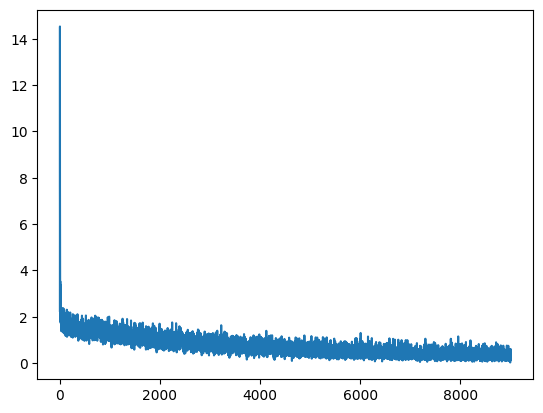

In [45]:
plt.plot(batch_number, batch_losses)
plt.show()

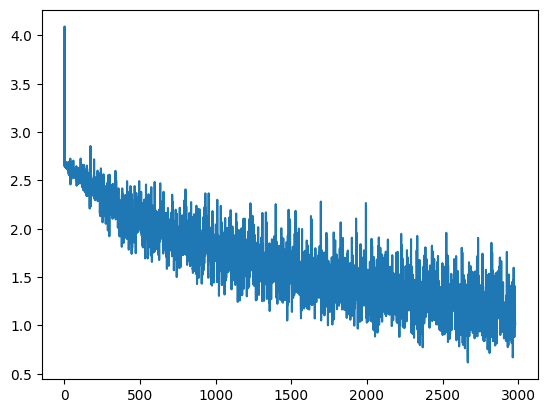

In [46]:
# Caminho para o arquivo salvo
checkpoint_path = f"./models/model_Category_balanced_14.pt"

# Carrega o checkpoint
checkpoint = torch.load(checkpoint_path)

# Acessa o batch_losses
batch_losses_14 = checkpoint["batch_losses"]

batch_number_14 = [i for i in range(len(batch_losses_14))]

plt.plot(batch_number_14, batch_losses_14)
plt.show()

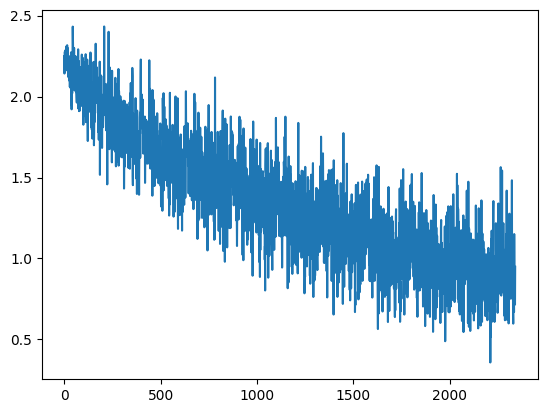

In [47]:
# Caminho para o arquivo salvo
checkpoint_path = f"./models/model_mapped_category_balanced.pt"

# Carrega o checkpoint
checkpoint = torch.load(checkpoint_path)

# Acessa o batch_losses
batch_losses_balanced = checkpoint["batch_losses"]

batch_number_balanced = [i for i in range(len(batch_losses_balanced))]

plt.plot(batch_number_balanced, batch_losses_balanced)
plt.show()

In [55]:
checkpoint_path = "./models/model_mapped_category_img64.pt"  # troque 'categoria' se necessário
checkpoint = torch.load(checkpoint_path, map_location="cpu")  # ou 'cuda' se estiver com GPU
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

Net(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=61504, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

In [54]:
image_size = (64, 64)

dummy_input = torch.randn(1, 1, image_size[0], image_size[1])

traced_model = torch.jit.trace(model, dummy_input)

traced_model.save(f"./models/model_categories.pt")